In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import io
import warnings
import multiprocessing as mp
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from scipy.fft import dctn
from scipy.ndimage import uniform_filter1d
from datasets import load_dataset

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, RocCurveDisplay
)

warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# ── Config ─────────────────────────────────────────────────────────────────────
SEED       = 42
N_TRAIN    = 10500
N_VAL      = 2500
N_TEST     = 2500
IMAGE_COL  = "image"
LABEL_COL  = "label"
CNN_EPOCHS = 40
CNN_BATCH  = 64
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

'''
# ── Dataset loading & splitting ────────────────────────────────────────────────
data = load_dataset("yanbax/CIFAKE_autotrain_compatible")

temp_split     = data["train"].train_test_split(test_size=0.2, seed=SEED)
train_data     = temp_split["train"]
temp_data      = temp_split["test"]
val_test_split = temp_data.train_test_split(test_size=0.5, seed=SEED)
val_data       = val_test_split["train"]
test_data      = val_test_split["test"]

train_data = train_data.shuffle(seed=SEED).select(range(N_TRAIN))
val_data   = val_data.shuffle(seed=SEED).select(range(N_VAL))
test_data  = test_data.shuffle(seed=SEED).select(range(N_TEST))


# ── Convert to numpy ───────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

def transform_example(example):
    example["pixel_values"] = transform(example[IMAGE_COL])
    return example

for split in [train_data, val_data, test_data]:
    split = split.map(transform_example, batched=False, num_proc=4)
    split.set_format(type="torch", columns=["pixel_values", LABEL_COL])

train_data = train_data.map(transform_example, batched=False, num_proc=4)
val_data   = val_data.map(transform_example, batched=False, num_proc=4)
test_data  = test_data.map(transform_example, batched=False, num_proc=4)
train_data.set_format(type="torch", columns=["pixel_values", LABEL_COL])
val_data.set_format(type="torch",   columns=["pixel_values", LABEL_COL])
test_data.set_format(type="torch",  columns=["pixel_values", LABEL_COL])

def tensor_to_numpy(img_tensor):
    return (img_tensor.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

def dataset_to_numpy(dataset):
    X = np.stack([tensor_to_numpy(x) for x in dataset["pixel_values"]])
    y = np.array(dataset[LABEL_COL])
    return X, y

X_train, y_train = dataset_to_numpy(train_data)
X_val,   y_val   = dataset_to_numpy(val_data)
X_test,  y_test  = dataset_to_numpy(test_data)'''




'\n# ── Dataset loading & splitting ────────────────────────────────────────────────\ndata = load_dataset("yanbax/CIFAKE_autotrain_compatible")\n\ntemp_split     = data["train"].train_test_split(test_size=0.2, seed=SEED)\ntrain_data     = temp_split["train"]\ntemp_data      = temp_split["test"]\nval_test_split = temp_data.train_test_split(test_size=0.5, seed=SEED)\nval_data       = val_test_split["train"]\ntest_data      = val_test_split["test"]\n\ntrain_data = train_data.shuffle(seed=SEED).select(range(N_TRAIN))\nval_data   = val_data.shuffle(seed=SEED).select(range(N_VAL))\ntest_data  = test_data.shuffle(seed=SEED).select(range(N_TEST))\n\n\n# ── Convert to numpy ───────────────────────────────────────────────────────────\ntransform = transforms.Compose([\n    transforms.Resize((32, 32)),\n    transforms.ToTensor(),\n])\n\ndef transform_example(example):\n    example["pixel_values"] = transform(example[IMAGE_COL])\n    return example\n\nfor split in [train_data, val_data, test_data]:

In [4]:
data = np.load("/content/drive/MyDrive/cifake_processed.npz")

X_train = data["X_train"]
y_train = data["y_train"]
X_val   = data["X_val"]
y_val   = data["y_val"]
X_test  = data["X_test"]
y_test  = data["y_test"]

# Feature Extraction

In [5]:
# ── Feature extraction ─────────────────────────────────────────────────────────
def batch_fft_features(X: np.ndarray, bins: int = 32) -> np.ndarray:

    #grayscale
    gray = X.mean(axis=3).astype(np.float32)
    N, H, W = gray.shape

    fft_shift = np.fft.fftshift(np.fft.fft2(gray), axes=(-2, -1))
    magnitude  = np.log1p(np.abs(fft_shift))   # (N, H, W)

    #radial distance map
    cy, cx = H // 2, W // 2
    y_idx, x_idx = np.ogrid[:H, :W]
    r = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)  # (H, W)
    max_r = r.max()

    features = np.zeros((N, bins), dtype=np.float32)
    for i in range(bins):
        mask = (r >= i * max_r / bins) & (r < (i + 1) * max_r / bins)
        if mask.any():
            features[:, i] = magnitude[:, mask].mean(axis=1)

    return features


#DCT features - instead of only keeping the mean of the low-freqcoefficients also keep std and max, tripling the information content.
def batch_dct_features(
    X: np.ndarray, block_size: int = 8, keep_coeff: int = 4
) -> np.ndarray:
    """
    DCT features with mean + std + max aggregation per coefficient.
    X : (N, H, W, C) uint8  →  (N, keep_coeff² × 3) float32
    """
    gray = X.mean(axis=3).astype(np.float32)
    N, H, W = gray.shape
    h_crop = H - (H % block_size)
    w_crop = W - (W % block_size)
    gray = gray[:, :h_crop, :w_crop]

    n_coeff = keep_coeff * keep_coeff
    # Collect per-block coefficients: shape (N, n_blocks, n_coeff)
    all_blocks = []
    for i in range(0, h_crop, block_size):
        for j in range(0, w_crop, block_size):
            block = gray[:, i:i+block_size, j:j+block_size]   # (N, 8, 8)
            # DCT applied to each image's block independently
            dct_block = np.array([
                dctn(b, norm='ortho')[:keep_coeff, :keep_coeff].flatten()
                for b in block
            ])                                                 # (N, n_coeff)
            all_blocks.append(dct_block)

    blocks = np.stack(all_blocks, axis=1)  # (N, n_blocks, n_coeff)

    #aggregate: mean + std + max
    feat_mean = blocks.mean(axis=1)        # (N, n_coeff)
    feat_std  = blocks.std(axis=1)
    feat_max  = blocks.max(axis=1)

    return np.concatenate([feat_mean, feat_std, feat_max], axis=1).astype(np.float32)


def motion_blur_batch(X: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    """Horizontal motion blur — ~10× faster than the np.convolve loop."""
    # uniform_filter1d is a C-level loop; operates on all N×H pixels at once
    blurred = uniform_filter1d(X.astype(np.float32), size=kernel_size, axis=2)
    return np.clip(blurred, 0, 255).astype(np.uint8)


def _jpeg_single(args):
    img_array, quality = args
    img = Image.fromarray(img_array.astype(np.uint8))
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality, subsampling=0, optimize=False)
    buf.seek(0)
    return np.array(Image.open(buf))

def apply_condition(X: np.ndarray, quality: int | None) -> np.ndarray:
    if quality is None:
        return X
    args = [(img, quality) for img in X]
    with mp.Pool(mp.cpu_count()) as pool:
        result = pool.map(_jpeg_single, args)
    return np.array(result, dtype=np.uint8)

def gaussian_noise_batch(X: np.ndarray, sigma: float = 15) -> np.ndarray:
    noise = np.random.normal(0, sigma, X.shape)
    return np.clip(X.astype(np.float32) + noise, 0, 255).astype(np.uint8)

def downscale_batch(X: np.ndarray, factor: int = 4) -> np.ndarray:
    result = []
    for img in X:
        img = img.astype(np.uint8)
        h, w = img.shape[:2]
        small    = Image.fromarray(img).resize((w // factor, h // factor), Image.BILINEAR)
        restored = small.resize((w, h), Image.BILINEAR)
        result.append(np.array(restored))
    return np.stack(result).astype(np.uint8)

In [6]:
#feature caching & extraction
fft_cache, dct_cache = {}, {}

def get_fft(X, key):
    if key not in fft_cache:
        fft_cache[key] = batch_fft_features(X)
    return fft_cache[key]

def get_dct(X, key):
    if key not in dct_cache:
        dct_cache[key] = batch_dct_features(X)
    return dct_cache[key]

print("Extracting pixel baseline features...")
X_train_pixel = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
X_val_pixel   = X_val.reshape(len(X_val),   -1).astype(np.float32) / 255.0
X_test_pixel  = X_test.reshape(len(X_test),  -1).astype(np.float32) / 255.0

print("Extracting FFT features...")
X_train_fft = get_fft(X_train, "train")
X_val_fft   = get_fft(X_val,   "val")
X_test_fft  = get_fft(X_test,  "test")

print("Extracting DCT features...")
X_train_dct = get_dct(X_train, "train")
X_val_dct   = get_dct(X_val,   "val")
X_test_dct  = get_dct(X_test,  "test")

print("Combining FFT + DCT...")
X_train_combined = np.hstack([X_train_fft, X_train_dct])
X_val_combined   = np.hstack([X_val_fft,   X_val_dct])
X_test_combined  = np.hstack([X_test_fft,  X_test_dct])

print("DONE")
print("Pixel features:",    X_train_pixel.shape,    X_test_pixel.shape)
print("FFT features:",      X_train_fft.shape,      X_test_fft.shape)
print("DCT features:",      X_train_dct.shape,      X_test_dct.shape)
print("Combined features:", X_train_combined.shape, X_test_combined.shape)

Extracting pixel baseline features...
Extracting FFT features...
Extracting DCT features...
Combining FFT + DCT...
DONE
Pixel features: (10500, 3072) (2500, 3072)
FFT features: (10500, 32) (2500, 32)
DCT features: (10500, 48) (2500, 48)
Combined features: (10500, 80) (2500, 80)


#Logistic Regression

In [7]:
#sklearn model definitions
def make_lr():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=500, solver="liblinear",
            class_weight="balanced", random_state=SEED,
            C=0.5,   #L2 regularisation helps on freq features
        ),
    )

#SVM with RBF kernel
def make_svm():
    return make_pipeline(
        StandardScaler(),
        SVC(
            kernel="rbf", C=1.0, gamma="scale",
            class_weight="balanced", probability=True,
            random_state=SEED,
        ),
    )

In [8]:
sklearn_models = {
    "Pixel LR Baseline": (make_lr(),  X_train_pixel,    X_val_pixel,    X_test_pixel),
    "LR + FFT":          (make_lr(),  X_train_fft,      X_val_fft,      X_test_fft),
    "LR + DCT":          (make_lr(),  X_train_dct,      X_val_dct,      X_test_dct),
    "LR + FFT + DCT":    (make_lr(),  X_train_combined, X_val_combined, X_test_combined),
    "SVM + FFT + DCT":   (make_svm(), X_train_combined, X_val_combined, X_test_combined),
    "MLP + FFT + DCT": (
        make_pipeline(
            StandardScaler(),
            MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                activation="relu",
                solver="adam",
                alpha=1e-3,
                learning_rate_init=1e-3,
                max_iter=100,
                early_stopping=True,
                validation_fraction=0.1,
                random_state=SEED,
            ),
        ),
        X_train_combined, X_val_combined, X_test_combined,
    ),
}

In [9]:
#Sklearn evaluation
def evaluate_model(model, X_eval, y_true):
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1] if hasattr(model, "predict_proba") else preds
    return {
        "accuracy":  accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall":    recall_score(y_true, preds, zero_division=0),
        "f1":        f1_score(y_true, preds, zero_division=0),
        "roc_auc":   roc_auc_score(y_true, probs),
    }

In [11]:
#Train sklearn models
rows, trained_models = [], {}

for name, (model, X_tr, X_val_, X_te) in sklearn_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_tr, y_train)
    val_metrics  = evaluate_model(model, X_val_, y_val)
    test_metrics = evaluate_model(model, X_te,   y_test)
    trained_models[name] = model
    rows.append({"model": name, **test_metrics})
    print(f"  val:  {val_metrics}")
    print(f"  test: {test_metrics}")




Training Pixel LR Baseline...
  val:  {'accuracy': 0.6604, 'precision': 0.6583897667419112, 'recall': 0.6889763779527559, 'f1': 0.6733358984224702, 'roc_auc': np.float64(0.7104327507842008)}
  test: {'accuracy': 0.6644, 'precision': 0.667167543200601, 'recall': 0.6915887850467289, 'f1': 0.6791586998087954, 'roc_auc': np.float64(0.7288765320134448)}

Training LR + FFT...
  val:  {'accuracy': 0.776, 'precision': 0.7808544303797469, 'recall': 0.7771653543307087, 'f1': 0.7790055248618785, 'roc_auc': np.float64(0.8529902054926061)}
  test: {'accuracy': 0.794, 'precision': 0.8073541167066347, 'recall': 0.7866043613707165, 'f1': 0.796844181459566, 'roc_auc': np.float64(0.8646934948352188)}

Training LR + DCT...
  val:  {'accuracy': 0.6888, 'precision': 0.6901081916537867, 'recall': 0.7031496062992126, 'f1': 0.6965678627145085, 'roc_auc': np.float64(0.7572985084181552)}
  test: {'accuracy': 0.6868, 'precision': 0.6919540229885057, 'recall': 0.7032710280373832, 'f1': 0.697566628041715, 'roc_au

# CNN

In [12]:
#CNN model definitions
#Conv block with BatchNorm + Dropout, stable training
def conv_block(in_ch: int, out_ch: int, dropout: float = 0.0) -> nn.Sequential:
    layers = [
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    ]
    if dropout > 0:
        layers.append(nn.Dropout2d(dropout))
    return nn.Sequential(*layers)

class SmallCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 64, dropout),
            conv_block(64, 128, dropout),
            conv_block(128, 256, dropout),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 2),
        )

    def forward(self, x, freq=None):
        return self.classifier(self.features(x))

In [13]:
#MLP branch for spectral features
# The freq features are projected into a shared embedding space before fusion,
# giving the model a chance to learn meaningful frequency representations.
class SmallCNNWithFreq(nn.Module):
    def __init__(self, freq_dim: int, embed_dim: int = 32, dropout: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3,  16, dropout=0.0),
            conv_block(16, 32, dropout=dropout),
            conv_block(32, 64, dropout=dropout),
        )
        # Two-layer MLP branch for spectral features
        self.freq_branch = nn.Sequential(
            nn.Linear(freq_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, embed_dim),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(64 * 4 * 4 + embed_dim, 2),
        )

    def forward(self, x, freq):
        cnn_feat  = self.features(x).flatten(1)
        freq_feat = self.freq_branch(freq)
        return self.classifier(torch.cat([cnn_feat, freq_feat], dim=1))

In [14]:
#CNN training utilities

#Data augmentation- random horizontal flip + colour jitter.
#applied only to the train loader, val,test stay clean.
AUGMENT = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
])

def make_image_tensor(X: np.ndarray, augment: bool = False) -> torch.Tensor:
    """(N,H,W,C) uint8 → (N,C,H,W) float32 in [0,1], optionally augmented."""
    t = torch.tensor(X).permute(0, 3, 1, 2).float() / 255.0
    if augment:
        t = torch.stack([AUGMENT(img) for img in t])
    return t

def make_loader(X_img, y, X_freq=None, batch_size=CNN_BATCH,
                shuffle=True, augment=False):
    tensors = [make_image_tensor(X_img, augment=augment), torch.tensor(y).long()]
    if X_freq is not None:
        tensors.append(torch.tensor(X_freq).float())
    return DataLoader(
        TensorDataset(*tensors),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True,
    )


def train_cnn(model, train_loader, val_loader, epochs=CNN_EPOCHS):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * 2, eta_min=1e-5)

    best_acc, best_state = 0.0, None

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            imgs, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            freq = batch[2].to(DEVICE) if len(batch) == 3 else None
            optimizer.zero_grad()
            criterion(model(imgs, freq), labels).backward()
            optimizer.step()

        scheduler.step()

        val_metrics = eval_cnn(model, val_loader)
        val_acc = val_metrics["accuracy"]
        print(f"  Epoch {epoch+1:02d}  lr={scheduler.get_last_lr()[0]:.5f}  val_acc={val_acc:.4f}")
        if val_acc > best_acc:
            best_acc  = val_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model


def eval_cnn(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            imgs, labels = batch[0].to(DEVICE), batch[1].to(DEVICE)
            freq   = batch[2].to(DEVICE) if len(batch) == 3 else None
            logits = model(imgs, freq)
            all_probs.append(torch.softmax(logits, 1)[:, 1].cpu())
            all_preds.append(logits.argmax(1).cpu())
            all_labels.append(labels.cpu())
    preds  = torch.cat(all_preds).numpy()
    probs  = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    return {
        "accuracy":  accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "f1":        f1_score(labels, preds, zero_division=0),
        "roc_auc":   roc_auc_score(labels, probs),
    }

In [15]:
#train CNN models
FFT_DIM      = X_train_fft.shape[1]
DCT_DIM      = X_train_dct.shape[1]
COMBINED_DIM = X_train_combined.shape[1]

cnn_variants = {
    "Vanilla CNN":     (SmallCNN(),                     None,             None,             None),
    "CNN + FFT":       (SmallCNNWithFreq(FFT_DIM),      X_train_fft,      X_val_fft,        X_test_fft),
    "CNN + DCT":       (SmallCNNWithFreq(DCT_DIM),      X_train_dct,      X_val_dct,        X_test_dct),
    "CNN + FFT + DCT": (SmallCNNWithFreq(COMBINED_DIM), X_train_combined, X_val_combined,   X_test_combined),
}

trained_cnns = {}

for name, (model, X_freq_tr, X_freq_val, X_freq_te) in cnn_variants.items():
    print(f"\nTraining {name}...")
    train_loader = make_loader(X_train, y_train, X_freq_tr, augment=True)
    val_loader   = make_loader(X_val,   y_val,   X_freq_val, shuffle=False)
    test_loader  = make_loader(X_test,  y_test,  X_freq_te,  shuffle=False)

    trained_model = train_cnn(model, train_loader, val_loader)
    trained_cnns[name] = (trained_model, test_loader)
    metrics = eval_cnn(trained_model, test_loader)
    rows.append({"model": name, **metrics})
    print(f"  {name} test: {metrics}")


Training Vanilla CNN...
  Epoch 01  lr=0.00100  val_acc=0.8248
  Epoch 02  lr=0.00100  val_acc=0.6756
  Epoch 03  lr=0.00100  val_acc=0.8740
  Epoch 04  lr=0.00099  val_acc=0.8440
  Epoch 05  lr=0.00099  val_acc=0.8520
  Epoch 06  lr=0.00099  val_acc=0.8964
  Epoch 07  lr=0.00098  val_acc=0.8928
  Epoch 08  lr=0.00098  val_acc=0.8924
  Epoch 09  lr=0.00097  val_acc=0.9036
  Epoch 10  lr=0.00096  val_acc=0.7928
  Epoch 11  lr=0.00095  val_acc=0.8620
  Epoch 12  lr=0.00095  val_acc=0.8896
  Epoch 13  lr=0.00094  val_acc=0.8940
  Epoch 14  lr=0.00093  val_acc=0.8956
  Epoch 15  lr=0.00092  val_acc=0.8824
  Epoch 16  lr=0.00091  val_acc=0.9116
  Epoch 17  lr=0.00089  val_acc=0.9076
  Epoch 18  lr=0.00088  val_acc=0.9172
  Epoch 19  lr=0.00087  val_acc=0.9184
  Epoch 20  lr=0.00086  val_acc=0.9048
  Epoch 21  lr=0.00084  val_acc=0.9116
  Epoch 22  lr=0.00083  val_acc=0.9088
  Epoch 23  lr=0.00081  val_acc=0.8968
  Epoch 24  lr=0.00080  val_acc=0.9168
  Epoch 25  lr=0.00078  val_acc=0.9152


# Evaluation

In [16]:
#clean-test results
results_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
print("\nAll model results (clean test):")
display(results_df.round(4))


All model results (clean test):


,model,accuracy,precision,recall,f1,roc_auc
0,Vanilla CNN,0.9356,0.9238,0.9533,0.9383,0.9813
1,CNN + DCT,0.9328,0.9312,0.9385,0.9348,0.9804
2,CNN + FFT + DCT,0.9288,0.9164,0.9478,0.9319,0.9798
3,CNN + FFT,0.9284,0.9151,0.9486,0.9315,0.9803
4,SVM + FFT + DCT,0.8472,0.8631,0.8349,0.8488,0.9210
5,MLP + FFT + DCT,0.8312,0.8367,0.8341,0.8354,0.9076
6,LR + FFT + DCT,0.8200,0.8283,0.8193,0.8238,0.8912
7,LR + FFT,0.7940,0.8074,0.7866,0.7968,0.8647
8,LR + DCT,0.6868,0.6920,0.7033,0.6976,0.7521
9,Pixel LR Baseline,0.6644,0.6672,0.6916,0.6792,0.7289


In [17]:
#robustness evaluation
#pre-cache for corrupted arrays and their features so the per-model loop doesn't redundantly recompute FFT/DCT for the same condition
conditions = {
    "Clean":        None,
    "JPEG-90":      lambda X: apply_condition(X, 90),
    "JPEG-70":      lambda X: apply_condition(X, 70),
    "JPEG-50":      lambda X: apply_condition(X, 50),
    "JPEG-30":      lambda X: apply_condition(X, 30),
    "Noise-σ10":    lambda X: gaussian_noise_batch(X, sigma=10),
    "Noise-σ25":    lambda X: gaussian_noise_batch(X, sigma=25),
    "Blur-k5":      lambda X: motion_blur_batch(X, kernel_size=5),
    "Blur-k9":      lambda X: motion_blur_batch(X, kernel_size=9),
    "Downscale-2x": lambda X: downscale_batch(X, factor=2),
    "Downscale-4x": lambda X: downscale_batch(X, factor=4),
}

print("\nPre-caching corrupted test arrays and features...")
cond_cache = {}
for cond_name, fn in conditions.items():
    print(f"  → {cond_name}")
    X_cond = X_test.copy() if fn is None else fn(X_test).astype(np.uint8)
    X_fft  = batch_fft_features(X_cond)
    X_dct  = batch_dct_features(X_cond)
    cond_cache[cond_name] = {
        "raw":      X_cond,
        "pixel":    X_cond.reshape(len(X_cond), -1).astype(np.float32) / 255.0,
        "fft":      X_fft,
        "fft+dct":  np.hstack([X_fft, X_dct]),
    }



Pre-caching corrupted test arrays and features...
  → Clean
  → JPEG-90
  → JPEG-70
  → JPEG-50
  → JPEG-30
  → Noise-σ10
  → Noise-σ25
  → Blur-k5
  → Blur-k9
  → Downscale-2x
  → Downscale-4x


In [18]:
robust_sklearn = ["Pixel LR Baseline", "LR + FFT", "LR + FFT + DCT", "SVM + FFT + DCT"]
robust_cnns    = ["Vanilla CNN",        "CNN + FFT", "CNN + FFT + DCT"]

robust_rows = []

for cond_name, cache in cond_cache.items():
    print(f"\nEvaluating {cond_name}...")

    sklearn_feature_map = {
        "Pixel LR Baseline": cache["pixel"],
        "LR + FFT":          cache["fft"],
        "LR + FFT + DCT":    cache["fft+dct"],
        "SVM + FFT + DCT":   cache["fft+dct"],
    }
    for model_name in robust_sklearn:
        metrics = evaluate_model(trained_models[model_name],
                                 sklearn_feature_map[model_name], y_test)
        robust_rows.append({"condition": cond_name, "model": model_name, **metrics})

    cnn_freq_map = {
        "Vanilla CNN":     None,
        "CNN + FFT":       cache["fft"],
        "CNN + FFT + DCT": cache["fft+dct"],
    }
    for model_name in robust_cnns:
        model, _ = trained_cnns[model_name]
        loader   = make_loader(cache["raw"], y_test,
                               cnn_freq_map[model_name], shuffle=False)
        metrics  = eval_cnn(model, loader)
        robust_rows.append({"condition": cond_name, "model": model_name, **metrics})

robustness_df = pd.DataFrame(robust_rows)
print("\nRobustness results:")
display(robustness_df.round(4))


Evaluating Clean...

Evaluating JPEG-90...

Evaluating JPEG-70...

Evaluating JPEG-50...

Evaluating JPEG-30...

Evaluating Noise-σ10...

Evaluating Noise-σ25...

Evaluating Blur-k5...

Evaluating Blur-k9...

Evaluating Downscale-2x...

Evaluating Downscale-4x...

Robustness results:


,condition,model,accuracy,precision,recall,f1,roc_auc
0,Clean,Pixel LR Baseline,0.6644,0.6672,0.6916,0.6792,0.7289
1,Clean,LR + FFT,0.7940,0.8074,0.7866,0.7968,0.8647
2,Clean,LR + FFT + DCT,0.8200,0.8283,0.8193,0.8238,0.8912
3,Clean,SVM + FFT + DCT,0.8472,0.8631,0.8349,0.8488,0.9210
4,Clean,Vanilla CNN,0.9356,0.9238,0.9533,0.9383,0.9813
...,...,...,...,...,...,...,...
72,Downscale-4x,LR + FFT + DCT,0.5228,0.5257,0.7235,0.6090,0.5284
73,Downscale-4x,SVM + FFT + DCT,0.4816,0.4779,0.1012,0.1671,0.4953
74,Downscale-4x,Vanilla CNN,0.6104,0.5724,0.9548,0.7157,0.7473
75,Downscale-4x,CNN + FFT,0.6412,0.6248,0.7547,0.6836,0.6938


# Visualization

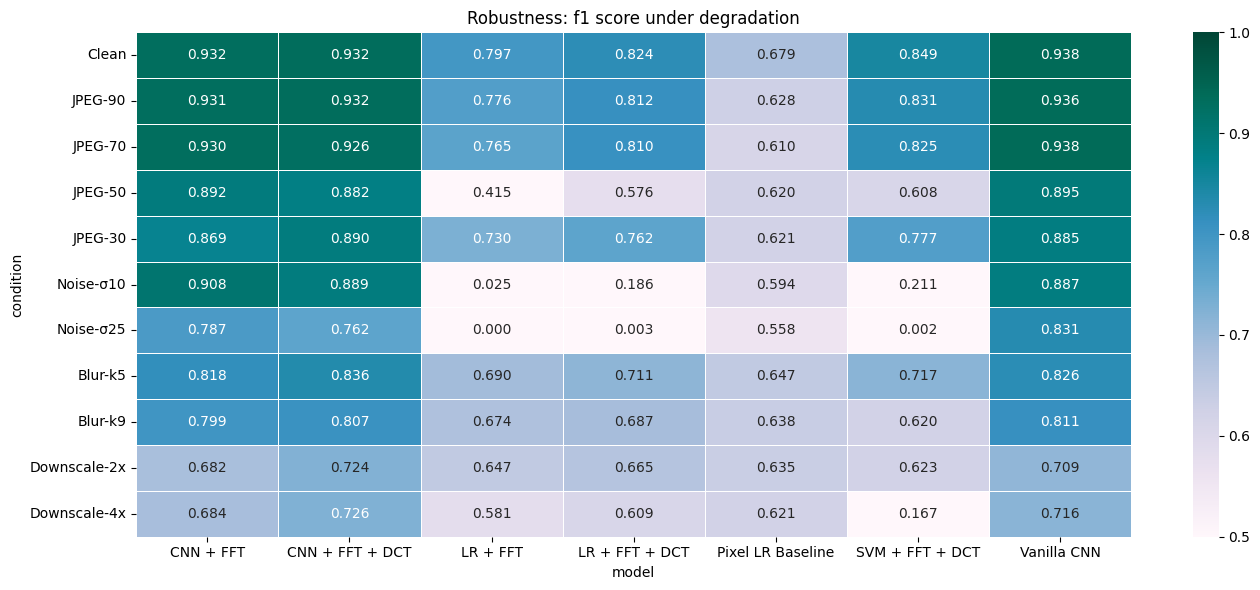

In [42]:
#robustness heatmap
pivot = robustness_df.pivot(index="condition", columns="model", values="f1")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="PuBuGn",
            vmin=0.5, vmax=1.0, linewidths=0.4)
plt.title("Robustness: f1 score under degradation")
plt.tight_layout()
plt.show()

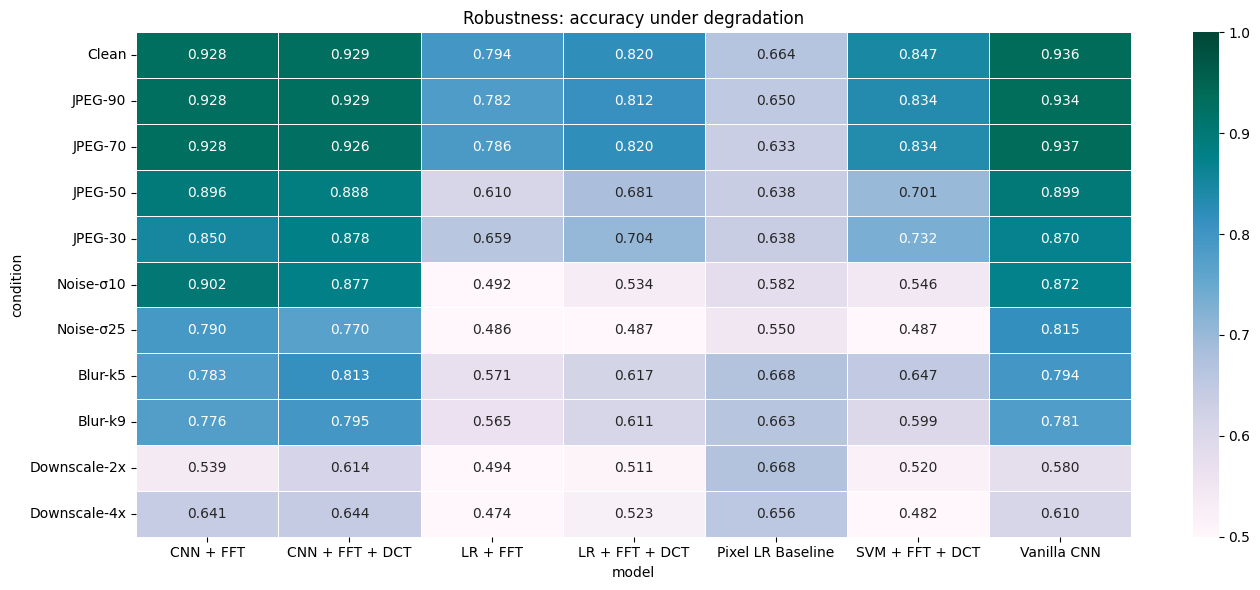

In [43]:
#robustness heatmap
pivot = robustness_df.pivot(index="condition", columns="model", values="accuracy")
plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="PuBuGn",
            vmin=0.5, vmax=1.0, linewidths=0.4)
plt.title("Robustness: accuracy under degradation")
plt.tight_layout()
plt.show()

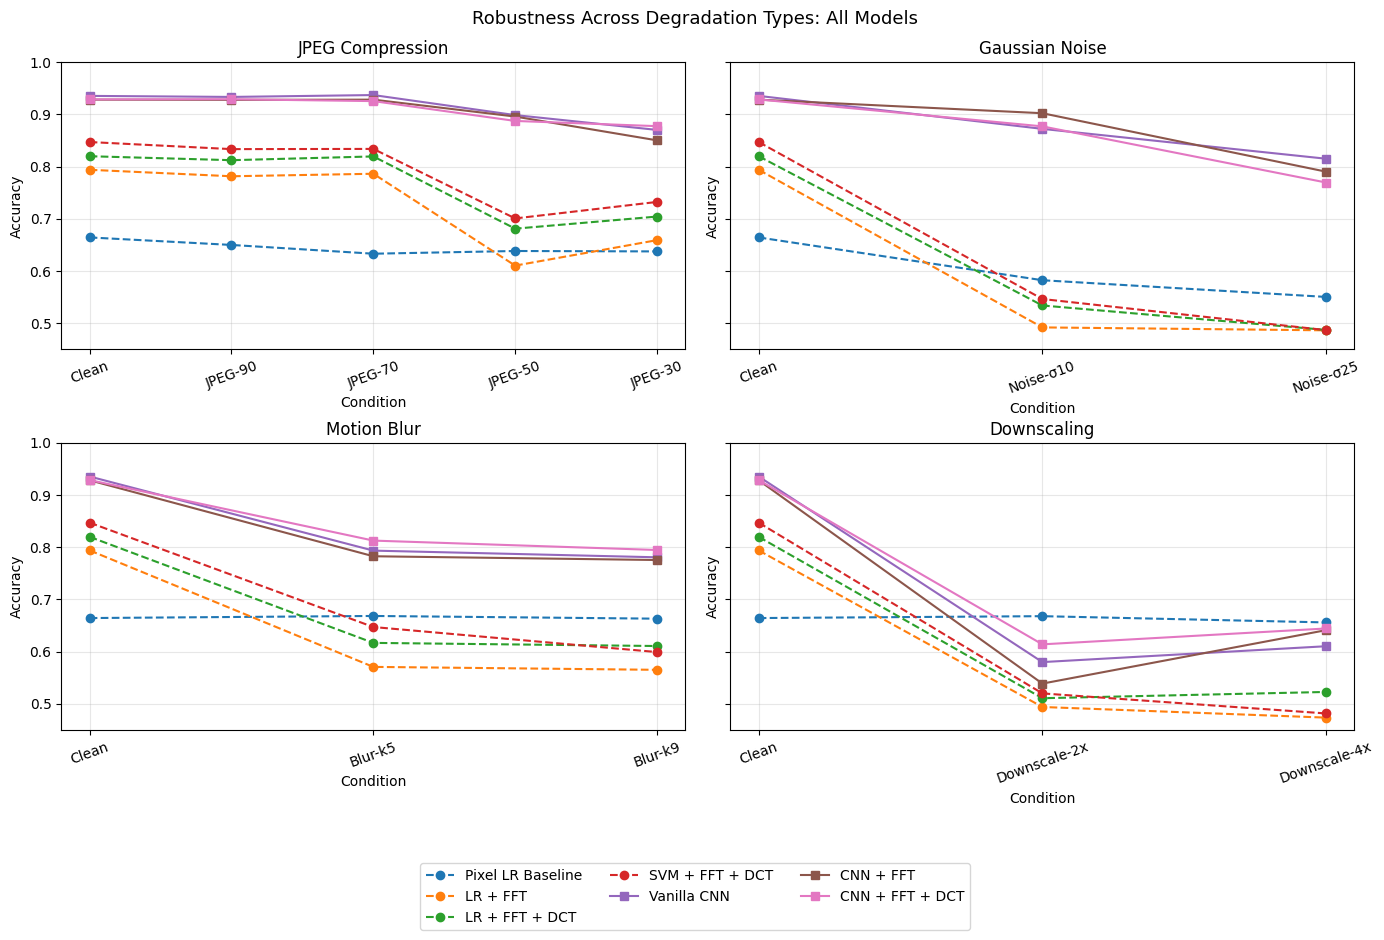

In [21]:
#robustness line plot
condition_order = list(conditions.keys())
robustness_df["condition"] = pd.Categorical(
    robustness_df["condition"], categories=condition_order, ordered=True
)
plot_robust = robustness_df.sort_values("condition")


#split conditions into groups for readable subplots
condition_groups = {
    "JPEG Compression": [c for c in condition_order if c.startswith("JPEG") or c == "Clean"],
    "Gaussian Noise":   [c for c in condition_order if c.startswith("Noise") or c == "Clean"],
    "Motion Blur":      [c for c in condition_order if c.startswith("Blur") or c == "Clean"],
    "Downscaling":      [c for c in condition_order if c.startswith("Downscale") or c == "Clean"],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for ax, (group_name, group_conds) in zip(axes, condition_groups.items()):
    sub = plot_robust[plot_robust["condition"].isin(group_conds)]

    #sklearn models
    for model_name in robust_sklearn:
        m = sub[sub["model"] == model_name]
        ax.plot(
            m["condition"], m["accuracy"],
            marker="o", linestyle="--", label=model_name
        )

    #CNN models
    for model_name in robust_cnns:
        m = sub[sub["model"] == model_name]
        ax.plot(
            m["condition"], m["accuracy"],
            marker="s", linestyle="-", label=model_name
        )

    ax.set_title(group_name)
    ax.set_xlabel("Condition")
    ax.set_ylabel("Accuracy")

    ax.set_ylim(0.45, 1.0)

    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=20)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Robustness Across Degradation Types: All Models", fontsize=13)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

In [22]:
#robustness summary metrics
# Mean accuracy across all degraded conditions
degraded_df = robustness_df[robustness_df["condition"] != "Clean"]

mean_acc = (
    degraded_df.groupby("model")["accuracy"]
    .mean()
    .sort_values(ascending=False)
    .rename("mean_degraded_acc")
)

#accuracy drop: clean accuracy minus mean degraded accuracy
clean_acc = (
    robustness_df[robustness_df["condition"] == "Clean"]
    .set_index("model")["accuracy"]
    .rename("clean_acc")
)

summary_df = pd.concat([clean_acc, mean_acc], axis=1)
summary_df["acc_drop"] = summary_df["clean_acc"] - summary_df["mean_degraded_acc"]
summary_df = summary_df.sort_values("mean_degraded_acc", ascending=False)

print("\nRobustness summary (all degradation types):")
display(summary_df.round(4))


Robustness summary (all degradation types):


,clean_acc,mean_degraded_acc,acc_drop
model,,,
CNN + FFT + DCT,0.9288,0.8133,0.1155
Vanilla CNN,0.9356,0.8092,0.1264
CNN + FFT,0.9284,0.8034,0.1250
SVM + FFT + DCT,0.8472,0.6382,0.2090
Pixel LR Baseline,0.6644,0.6348,0.0296
LR + FFT + DCT,0.8200,0.6300,0.1900
LR + FFT,0.7940,0.5920,0.2020


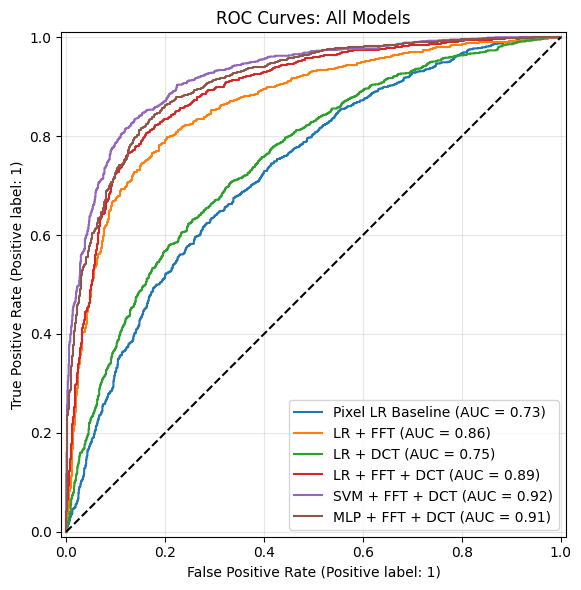

In [23]:
feature_map = {
    "Pixel LR Baseline": X_test_pixel,
    "LR + FFT":          X_test_fft,
    "LR + DCT":          X_test_dct,
    "LR + FFT + DCT":    X_test_combined,
    "MLP + FFT + DCT":   X_test_combined,
    "SVM + FFT + DCT":   X_test_combined,
}

fig, ax = plt.subplots(figsize=(7, 6))

for name, model in trained_models.items():
    probs = model.predict_proba(feature_map[name])[:, 1]
    RocCurveDisplay.from_predictions(y_test, probs, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("ROC Curves: All Models")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

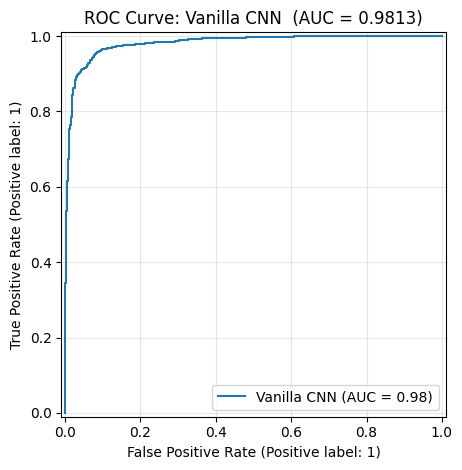

In [24]:
best_model_name = results_df.iloc[0]["model"]

if best_model_name in trained_models:
    best_model = trained_models[best_model_name]
    best_probs = best_model.predict_proba(feature_map[best_model_name])[:, 1]
else:
    #CNN
    best_cnn, best_loader = trained_cnns[best_model_name]
    best_cnn.eval()
    all_probs = []
    with torch.no_grad():
        for batch in best_loader:
            imgs = batch[0].to(DEVICE)
            freq = batch[2].to(DEVICE) if len(batch) == 3 else None
            logits = best_cnn(imgs, freq)
            all_probs.append(torch.softmax(logits, dim=1)[:, 1].cpu())
    best_probs = torch.cat(all_probs).numpy()

auc = roc_auc_score(y_test, best_probs)

RocCurveDisplay.from_predictions(y_test, best_probs, name=best_model_name)
plt.title(f"ROC Curve: {best_model_name}  (AUC = {auc:.4f})")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
degraded_df = robustness_df[robustness_df["condition"] != "Clean"]

mean_acc = (
    degraded_df.groupby("model")["accuracy"]
    .mean().sort_values(ascending=False)
    .rename("mean_degraded_acc")
)
clean_acc = (
    robustness_df[robustness_df["condition"] == "Clean"]
    .set_index("model")["accuracy"].rename("clean_acc")
)
summary_df = pd.concat([clean_acc, mean_acc], axis=1)
summary_df["acc_drop"] = summary_df["clean_acc"] - summary_df["mean_degraded_acc"]


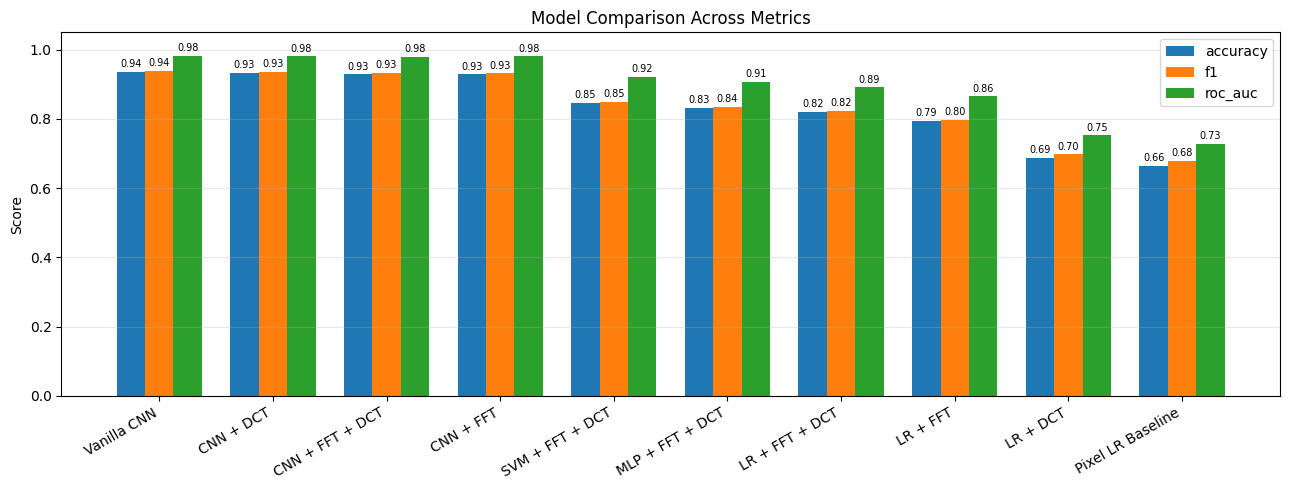

In [26]:
metrics = ["accuracy", "f1", "roc_auc"]

x = np.arange(len(results_df))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))

for i, m in enumerate(metrics):
    bars = ax.bar(x + i * width, results_df[m], width, label=m)
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=7)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df["model"], rotation=30, ha="right")

ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison Across Metrics")
ax.set_ylabel("Score")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

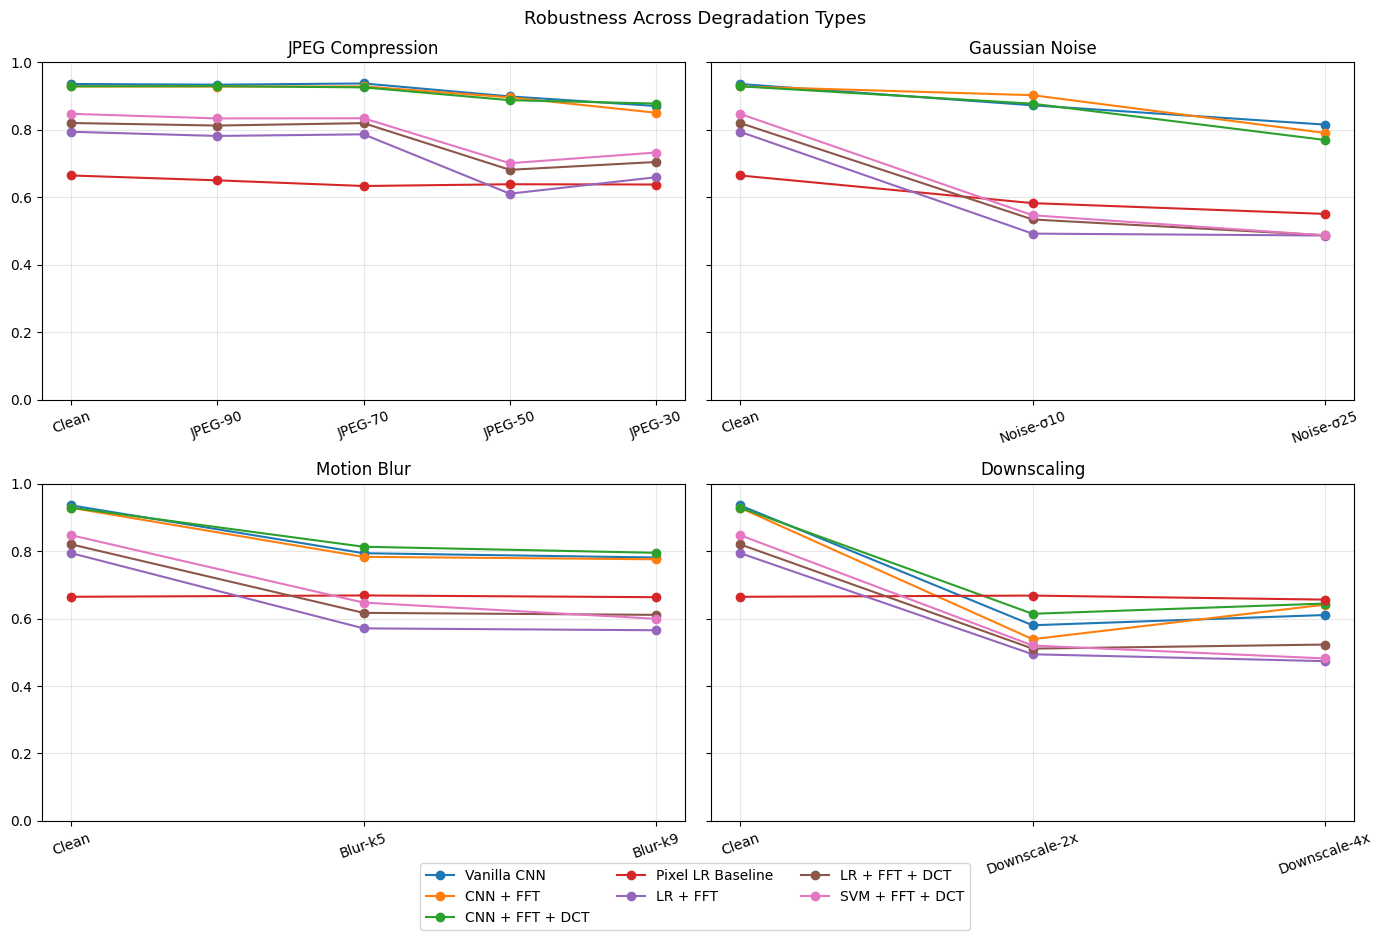

In [27]:
condition_groups = {
    "JPEG Compression": [c for c in condition_order if c.startswith("JPEG") or c == "Clean"],
    "Gaussian Noise":   [c for c in condition_order if c.startswith("Noise") or c == "Clean"],
    "Motion Blur":      [c for c in condition_order if c.startswith("Blur") or c == "Clean"],
    "Downscaling":      [c for c in condition_order if c.startswith("Downscale") or c == "Clean"],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
for ax, (group_name, group_conds) in zip(axes.flatten(), condition_groups.items()):
    sub = robustness_df[robustness_df["condition"].isin(group_conds)]
    for model_name in robust_cnns + robust_sklearn:
        m = sub[sub["model"] == model_name]
        ax.plot(m["condition"], m["accuracy"], marker="o", label=model_name)
    ax.set_title(group_name)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", rotation=20)

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Robustness Across Degradation Types", fontsize=13)
plt.tight_layout()

In [28]:
display(robustness_df.pivot(index="condition", columns="model", values="accuracy")
        .loc[condition_order].round(4))

model,CNN + FFT,CNN + FFT + DCT,LR + FFT,LR + FFT + DCT,Pixel LR Baseline,SVM + FFT + DCT,Vanilla CNN
condition,,,,,,,
Clean,0.9284,0.9288,0.7940,0.8200,0.6644,0.8472,0.9356
JPEG-90,0.9280,0.9292,0.7816,0.8124,0.6500,0.8336,0.9336
JPEG-70,0.9284,0.9256,0.7864,0.8196,0.6332,0.8340,0.9372
JPEG-50,0.8960,0.8876,0.6104,0.6812,0.6384,0.7008,0.8988
JPEG-30,0.8504,0.8776,0.6592,0.7044,0.6376,0.7324,0.8704
Noise-σ10,0.9024,0.8772,0.4920,0.5340,0.5824,0.5464,0.8724
Noise-σ25,0.7904,0.7696,0.4864,0.4872,0.5504,0.4868,0.8152
Blur-k5,0.7828,0.8128,0.5708,0.6168,0.6684,0.6472,0.7936
Blur-k9,0.7756,0.7948,0.5652,0.6108,0.6632,0.5992,0.7808


In [29]:
display(robustness_df.pivot(index="condition", columns="model", values="roc_auc")
        .loc[condition_order].round(4))

model,CNN + FFT,CNN + FFT + DCT,LR + FFT,LR + FFT + DCT,Pixel LR Baseline,SVM + FFT + DCT,Vanilla CNN
condition,,,,,,,
Clean,0.9803,0.9798,0.8647,0.8912,0.7289,0.9210,0.9813
JPEG-90,0.9796,0.9791,0.8545,0.8832,0.7109,0.9151,0.9807
JPEG-70,0.9801,0.9801,0.8720,0.8978,0.6980,0.9216,0.9816
JPEG-50,0.9707,0.9669,0.8120,0.8550,0.6943,0.8771,0.9688
JPEG-30,0.9581,0.9642,0.7436,0.8076,0.6995,0.8523,0.9660
Noise-σ10,0.9658,0.9650,0.7137,0.7847,0.6182,0.7944,0.9717
Noise-σ25,0.8862,0.8663,0.5535,0.6668,0.5776,0.6026,0.8996
Blur-k5,0.8882,0.8964,0.7048,0.7526,0.7319,0.6873,0.8973
Blur-k9,0.8621,0.8658,0.6640,0.7041,0.7287,0.6370,0.8670


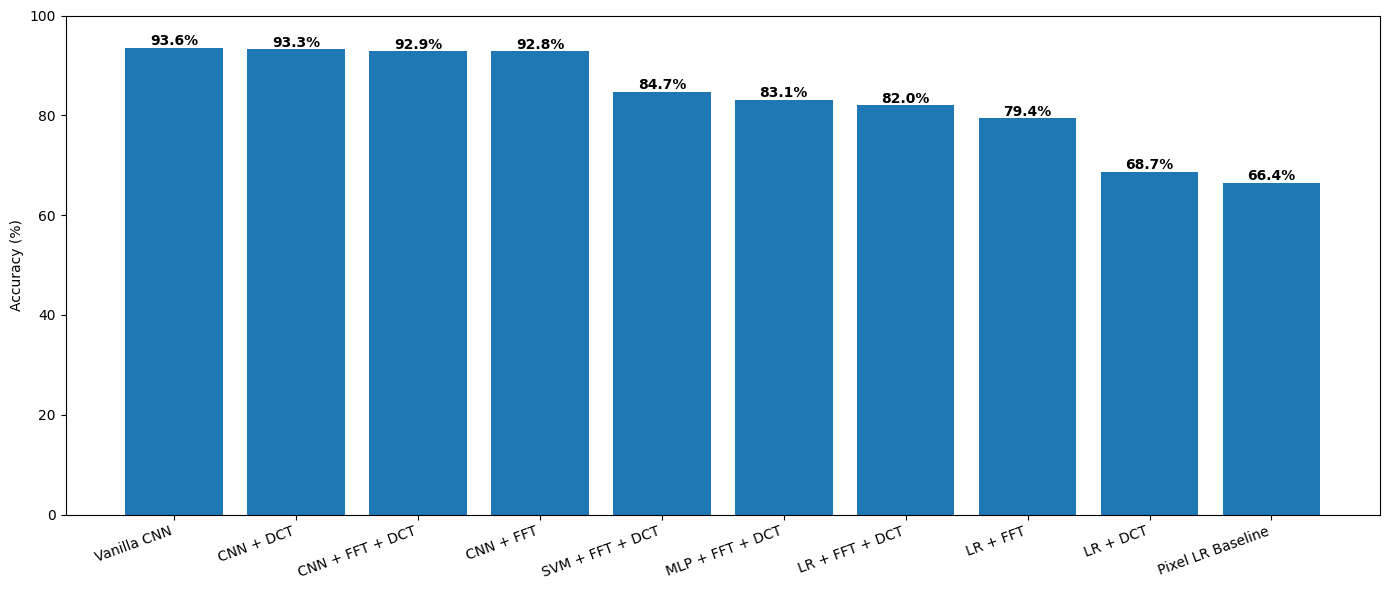

In [30]:
plt.figure(figsize=(14, 6))

bars = plt.bar(results_df["model"], results_df["accuracy"] * 100)

for bar, val in zip(bars, results_df["accuracy"] * 100):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.xticks(rotation=20, ha="right")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()